# 06. Métricas de evaluación para modelos de clasificación

La evaluación de un modelo de clasificación mide cuán bien generaliza sus predicciones sobre datos nuevos no vistos durante el entrenamiento.

Todas las métricas que veremos en este notebook se calculan a partir de la **matriz de confusión**, una tabla que cruza las predicciones del modelo con las etiquetas reales.

Las métricas que cubriremos son:

- **Matriz de confusión:** tabla base que resume todos los aciertos y errores del clasificador.
- **Accuracy:** porcentaje global de acierto.
- **Precision:** de todo lo que el modelo predice como positivo, ¿cuánto realmente lo es?
- **Recall:** de todo lo que realmente es positivo, ¿cuánto detecta el modelo?
- **F-Score:** media armónica entre Precision y Recall.
- **Curva ROC y ROC-AUC:** representación gráfica de la capacidad discriminativa del modelo.

Para cada métrica seguiremos el mismo esquema: primero explicamos el concepto, luego lo calculamos a mano con un ejemplo sencillo y por último lo verificamos con **scikit-learn**.

---

## 0. Ejemplo de trabajo y datos de partida

A lo largo del notebook utilizaremos el siguiente caso de clasificación binaria.

Supongamos que tenemos 10 elementos y el clasificador produce las siguientes predicciones:

```python
y_real    = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
y_predict = [1, 1, 0, 1, 1, 0, 0, 1, 1, 0]
```

Antes de calcular ninguna métrica, analicemos qué ha ocurrido en cada posición:

| Posición | Real | Predicho | Resultado |
|:---:|:---:|:---:|:---|
| 0 | 1 | 1 | **TP** — acierto positivo |
| 1 | 1 | 1 | **TP** — acierto positivo |
| 2 | 1 | 0 | **FN** — fallo: era 1, predicho como 0 |
| 3 | 1 | 1 | **TP** — acierto positivo |
| 4 | 1 | 1 | **TP** — acierto positivo |
| 5 | 0 | 0 | **TN** — acierto negativo |
| 6 | 0 | 0 | **TN** — acierto negativo |
| 7 | 0 | 1 | **FP** — fallo: era 0, predicho como 1 |
| 8 | 0 | 1 | **FP** — fallo: era 0, predicho como 1 |
| 9 | 0 | 0 | **TN** — acierto negativo |

**Resumen: TP = 4, FN = 1, FP = 2, TN = 3**

Usaremos estos valores para calcular cada métrica a mano antes de verificar el resultado con scikit-learn.

In [1]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import itertools
%matplotlib inline

y_real    = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
y_predict = [1, 1, 0, 1, 1, 0, 0, 1, 1, 0]

---

## 1. Matriz de confusión

La **matriz de confusión** es una tabla que resume los resultados de un clasificador cruzando las predicciones del modelo con las etiquetas reales. Para un problema de clasificación binaria tiene cuatro celdas:

- **True Positive (TP):** valores positivos clasificados correctamente como positivos.
- **True Negative (TN):** valores negativos clasificados correctamente como negativos.
- **False Positive (FP):** valores negativos clasificados incorrectamente como positivos.
- **False Negative (FN):** valores positivos clasificados incorrectamente como negativos.

<img src='imgs/001_matriz_confusion.png' width='500'/>

Aplicado a nuestro ejemplo:

```
                  Predicho 1    Predicho 0
  Real 1    |      TP = 4    |   FN = 1   |
  Real 0    |      FP = 2    |   TN = 3   |
```

In [2]:
cm = confusion_matrix(y_true=y_real, y_pred=y_predict, labels=[1, 0])

print('Matriz de confusión:')
print(cm)
print()

TP = cm[0, 0]
FN = cm[0, 1]
FP = cm[1, 0]
TN = cm[1, 1]

print(f'  TP={TP}  FN={FN}')
print(f'  FP={FP}  TN={TN}')

Matriz de confusión:
[[4 1]
 [2 3]]

  TP=4  FN=1
  FP=2  TN=3


---

## 2. Accuracy (Exactitud)

La **exactitud** (*accuracy*) indica el porcentaje global de acierto del modelo: de todos los elementos clasificados, ¿cuántos ha acertado?

<img src='imgs/002_accuracy.png' width='500'/>

> **Importante:** el accuracy puede ser engañoso cuando las clases están desbalanceadas. Por ejemplo, si el 95 % de los correos de un dataset son legítimos, un clasificador que etiquete todo como *no spam* tendría un accuracy del 95 % sin haber aprendido nada útil. Para estos casos, las métricas de Precision, Recall y F-Score ofrecen información más fiable.

**Cálculo manual:**

**TP = 4, FN = 1, FP = 2, TN = 3**

$$Accuracy = \frac{TP + TN}{TP + FN + FP + TN} = \frac{4 + 3}{4 + 1 + 2 + 3} = \frac{7}{10} = 0.7$$

In [3]:
acc = accuracy_score(y_true=y_real, y_pred=y_predict)
print(f'Accuracy: {acc:.2f}')

Accuracy: 0.70


---

## 3. Precision (Precisión)

La **precisión** mide los positivos correctamente pronosticados entre todos los ejemplos que el modelo ha pronosticado como positivos.

> *"De lo que hemos pronosticado como positivo, ¿cuánto hemos acertado?"*

<img src='imgs/003_precision.png' width='500'/>

**Cálculo manual:**

**TP = 4, FN = 1, FP = 2, TN = 3**

$$Precision = \frac{TP}{TP + FP} = \frac{4}{4 + 2} = \frac{4}{6} \approx 0.67$$

El modelo predijo como positivos 6 elementos (4 TP + 2 FP). De esos 6, únicamente 4 eran realmente positivos.

In [4]:
prec = precision_score(y_true=y_real, y_pred=y_predict)
print(f'Precision: {prec:.2f}')

Precision: 0.67


---

## 4. Recall (Exhaustividad / Sensibilidad)

El **recall** mide los positivos correctamente pronosticados entre todos los ejemplos que realmente son positivos.

> *"De lo que hay en realidad como positivo, ¿cuánto hemos detectado?"*

Esta medida también se conoce como **exhaustividad** o **sensibilidad**.

<img src='imgs/004_recall.png' width='500'/>

**Cálculo manual:**

**TP = 4, FN = 1, FP = 2, TN = 3**

$$Recall = \frac{TP}{TP + FN} = \frac{4}{4 + 1} = \frac{4}{5} = 0.8$$

De los 5 elementos que realmente eran positivos, el modelo acertó 4 y falló 1 (lo clasificó como negativo).

---

**Precision vs Recall — trade-off:** estas dos métricas suelen presentar un equilibrio inverso. Si el modelo se vuelve más conservador y solo clasifica como positivo cuando está muy seguro, aumenta la Precision pero baja el Recall. Si el modelo clasifica como positivo más elementos para no dejar escapar ninguno, sube el Recall pero puede bajar la Precision.

In [5]:
rec = recall_score(y_true=y_real, y_pred=y_predict)
print(f'Recall: {rec:.2f}')

Recall: 0.80


---

## 5. F-Score

El **F-Score** combina la Precision y el Recall en una sola medida mediante su **media armónica**. Se usa la media armónica y no la media aritmética porque penaliza los casos en los que uno de los dos valores es muy bajo: si un modelo tiene Precision alta pero Recall casi nulo, o viceversa, el F-Score lo reflejará con un valor bajo.

- Un valor cercano a **1** indica una buena clasificación.
- Un valor cercano a **0** indica una mala clasificación.

La versión más habitual es el **F1**, que otorga el mismo peso a la Precision y al Recall:

<img src='imgs/005_f1.png' width='500'/>

**Cálculo manual:**

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall} = 2 \cdot \frac{0.67 \cdot 0.8}{0.67 + 0.8} = 2 \cdot \frac{0.54}{1.47} \approx 0.73$$

---

En realidad, la fórmula general se denomina $F_\beta$ y permite ajustar la importancia relativa de cada métrica según la tarea:

<img src='imgs/006_fscore.png' width='500'/>

El parámetro $\beta$ determina el énfasis:

- $F_{0.5}$: da más peso a la Precision que al Recall. Útil cuando los falsos positivos son más costosos.
- $F_{1}$: equilibra ambas métricas por igual.
- $F_{2}$: da más peso al Recall que a la Precision. Útil cuando los falsos negativos son muy costosos (por ejemplo, en diagnóstico médico no conviene dejar escapar un caso positivo).

In [6]:
f1 = f1_score(y_true=y_real, y_pred=y_predict)
print(f'F1-Score: {f1:.2f}')

F1-Score: 0.73


---

## 6. Resumen de métricas con `classification_report`

scikit-learn ofrece la función `classification_report()` que calcula de una sola vez la Precision, el Recall y el F1-Score para cada clase, junto con el Accuracy global.

También incluye la columna `support`, que indica cuántos elementos de cada clase hay en los datos reales. El reporte incluye además dos promedios:

- **macro avg:** promedio aritmético de cada métrica por clase, sin tener en cuenta el tamaño de cada clase.
- **weighted avg:** promedio ponderado por el número de elementos de cada clase.

In [7]:
print(classification_report(y_true=y_real, y_pred=y_predict))

              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



---

## 7. Visualización: heatmap de la matriz de confusión

Para representar la matriz de confusión de forma visual, podemos usar un **heatmap** con Matplotlib. La intensidad del color indica el volumen de predicciones: las celdas más oscuras corresponden a los valores más altos.

Definimos una función reutilizable `plot_confusion_matrix()` que recibirá la matriz, las etiquetas de clase y el título.

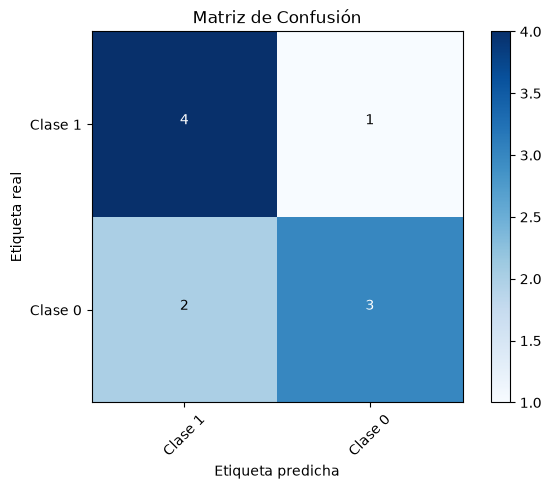

In [8]:
def plot_confusion_matrix(cm, classes, title, cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Etiqueta real')
    plt.xlabel('Etiqueta predicha')


plt.figure()
cm_binary = confusion_matrix(y_true=y_real, y_pred=y_predict, labels=[1, 0])
plot_confusion_matrix(cm_binary, classes=['Clase 1', 'Clase 0'], title='Matriz de Confusión')
plt.show()

---

## 8. Curva ROC y ROC-AUC

La **curva ROC** (*Receiver Operating Characteristic*) es una gráfica que representa la Tasa de Verdaderos Positivos (TPR = Recall) en el eje vertical frente a la Tasa de Falsos Positivos (FPR) en el eje horizontal:

$$TPR = Recall = \frac{TP}{TP + FN} \qquad FPR = \frac{FP}{FP + TN}$$

<img src='imgs/006_roc_auc.png' width='500'/>

**¿Cómo se construye la curva?**

1. El modelo asigna a cada elemento una **probabilidad de pertenecer a la clase positiva**.
2. Ordenamos los elementos de mayor a menor probabilidad.
3. Vamos bajando el **umbral de decisión** de forma progresiva, incorporando elementos como positivos uno a uno:
   - Si el elemento incorporado es realmente positivo → la curva **sube verticalmente** (aumenta el TPR).
   - Si el elemento incorporado es realmente negativo → la curva **avanza hacia la derecha** (aumenta el FPR).

---

El **ROC-AUC** (*Area Under the Curve*) es el área bajo la curva ROC y mide la capacidad global del clasificador para distinguir entre las dos clases:

- **ROC-AUC = 1:** clasificador perfecto.
- **ROC-AUC = 0.5:** equivale a clasificar de forma aleatoria (corresponde a la diagonal).
- Cuanto más próxima esté la curva a la **esquina superior izquierda**, mejor es el modelo.

En el siguiente ejemplo generamos un dataset sintético de 1000 elementos, entrenamos una regresión logística y representamos su curva ROC junto con la línea base de un clasificador aleatorio.

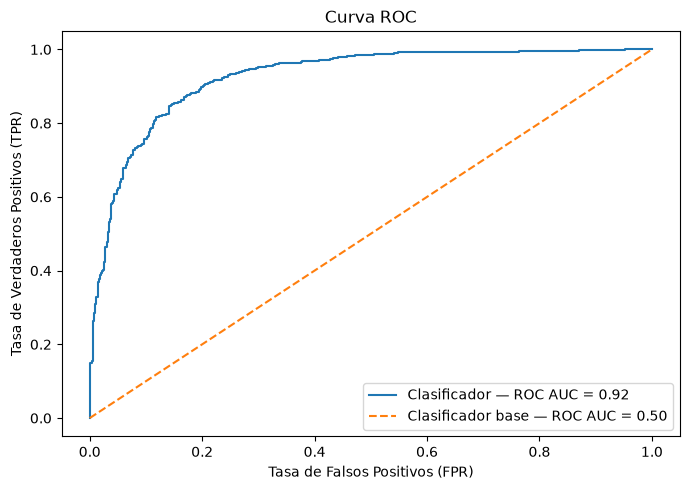

ROC-AUC del clasificador:      0.92
ROC-AUC del clasificador base: 0.50


In [9]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Generamos un dataset sintético de clasificación binaria
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

# Entrenamos el clasificador y obtenemos probabilidades por clase
clf = LogisticRegression(solver='lbfgs', max_iter=1000)
clf.fit(X, y)
y_probs = clf.predict_proba(X)[:, 1]

# Clasificador base: asigna probabilidad 0 a todos los elementos
y_base = [0] * len(y)

# Obtenemos FPR y TPR para cada umbral
base_fpr, base_tpr, _ = roc_curve(y, y_base)
clf_fpr,  clf_tpr,  _ = roc_curve(y, y_probs)

# Calculamos el ROC-AUC
base_auc = roc_auc_score(y, y_base)
clf_auc  = roc_auc_score(y, y_probs)

# Pintamos la curva ROC
plt.figure(figsize=(7, 5))
plt.plot(clf_fpr,  clf_tpr,  label=f'Clasificador — ROC AUC = {clf_auc:.2f}')
plt.plot(base_fpr, base_tpr, linestyle='--', label=f'Clasificador base — ROC AUC = {base_auc:.2f}')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

print(f'ROC-AUC del clasificador:      {clf_auc:.2f}')
print(f'ROC-AUC del clasificador base: {base_auc:.2f}')

---

## 9. Clasificación múltiple

Para problemas con más de dos clases, las métricas se calculan de la misma forma, pero **por separado para cada clase**, tratando esa clase como la positiva y el resto de clases como negativas en cada cálculo.

Por ejemplo, con tres clases (0, 1 y 2):

- **Clase 0 como positiva:** el resto de elementos se consideran negativos.
- **Clase 1 como positiva:** ídem.
- **Clase 2 como positiva:** ídem.

scikit-learn realiza este proceso automáticamente. La función `classification_report()` devuelve las métricas para cada clase más una media global.

Veamos el siguiente ejemplo:

```python
y_real    = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]
y_predict = [1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 2, 1, 1, 0, 2]
```

In [10]:
y_real_mc    = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]
y_predict_mc = [1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 2, 1, 1, 0, 2]

print('Reporte de clasificación multiclase:')
print(classification_report(y_true=y_real_mc, y_pred=y_predict_mc))

Reporte de clasificación multiclase:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.50      0.80      0.62         5
           2       1.00      0.40      0.57         5

    accuracy                           0.60        15
   macro avg       0.70      0.60      0.60        15
weighted avg       0.70      0.60      0.60        15



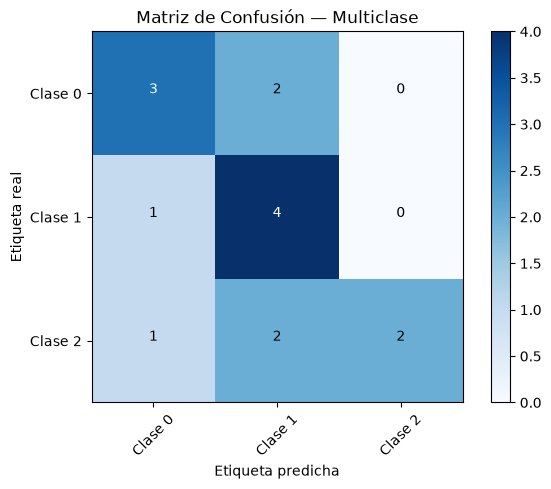

In [11]:
plt.figure()
cm_mc = confusion_matrix(y_true=y_real_mc, y_pred=y_predict_mc, labels=[0, 1, 2])
plot_confusion_matrix(cm_mc, classes=['Clase 0', 'Clase 1', 'Clase 2'], title='Matriz de Confusión — Multiclase')
plt.show()

---

## 10. Conclusiones

En este notebook hemos visto las principales métricas de evaluación para modelos de clasificación:

- La **matriz de confusión** es la base de todas las métricas: resume los TP, TN, FP y FN del clasificador.

- El **Accuracy** indica el porcentaje global de acierto, pero puede ser engañoso cuando las clases están desbalanceadas.

- La **Precision** responde a *'de lo que predigo como positivo, ¿cuánto acierto?'* y el **Recall** a *'de lo que realmente es positivo, ¿cuánto detecto?'*. Ambas métricas suelen presentar un trade-off inverso.

- El **F1-Score** combina Precision y Recall mediante la media armónica, penalizando cuando una de las dos es muy baja. La versión $F_\beta$ permite ajustar el peso de cada métrica según la tarea.

- La **curva ROC** visualiza el rendimiento del clasificador en todos los umbrales posibles. El **ROC-AUC** condensa esa información en un único valor entre 0.5 y 1: cuanto más cercano a 1, mejor es el modelo.

Estas métricas son fundamentales en cualquier pipeline de NLP o aprendizaje automático para evaluar si un modelo clasificador funciona correctamente antes de ponerlo en producción.